## Exercise 1: Few-Shot Learning & Augmentation
**Dataset Used:** CIFAR-10 (Subset)

1. Few-Shot: Train on 10, 100, 500 shots.
2. Implement Augmentation (RandomFlip, RandomRotation).
3. Prototypical Networks Concept.


Training 10-Shot...



Training 50-Shot...



Training 100-Shot...


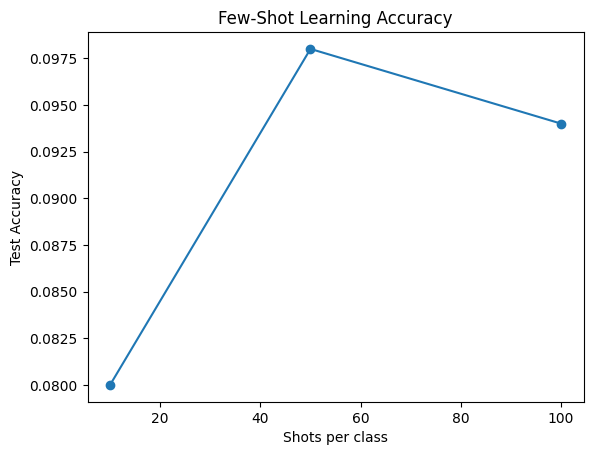

10-Shot Accuracy (No Aug): 0.0800
10-Shot Accuracy (With Aug): 0.1120

Prototypical Networks: These networks map inputs to an embedding space where each class is represented by a 'prototype', which is the mean vector of its support examples. Classification is done by finding the nearest prototype using a distance metric (e.g., Euclidean distance).


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Input, RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_test_sub = x_test[:500].astype('float32') / 255.
y_test_sub = y_test[:500]

def get_few_shot_data(shots):
    idx = []
    for c in range(10):
        c_idx = np.where(y_train == c)[0][:shots]
        idx.extend(c_idx)
    np.random.shuffle(idx)
    return x_train[idx].astype('float32') / 255., y_train[idx]

def build_model(use_aug=False):
    inputs = Input(shape=(32, 32, 3))
    x = inputs
    if use_aug:
        data_augmentation = Sequential([
            RandomFlip("horizontal"),
            RandomRotation(0.1),
            RandomZoom(0.1),
        ])
        x = data_augmentation(x)
        
    base = EfficientNetB0(input_shape=(32, 32, 3), include_top=False, weights='imagenet')
    base.trainable = False
    x = base(x, training=False)
    x = GlobalAveragePooling2D()(x)
    outputs = Dense(10, activation='softmax')(x)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

shots = [10, 50, 100]
accs = []

for s in shots:
    print(f"\nTraining {s}-Shot...")
    x_s, y_s = get_few_shot_data(s)
    model = build_model()
    model.fit(x_s, y_s, epochs=1, verbose=0)
    _, acc = model.evaluate(x_test_sub, y_test_sub, verbose=0)
    accs.append(acc)

plt.plot(shots, accs, marker='o')
plt.title("Few-Shot Learning Accuracy")
plt.xlabel("Shots per class")
plt.ylabel("Test Accuracy")
plt.show()

# With Augmentation
x_10, y_10 = get_few_shot_data(10)
model_aug = build_model(use_aug=True)
model_aug.fit(x_10, y_10, epochs=1, verbose=0)
_, acc_aug = model_aug.evaluate(x_test_sub, y_test_sub, verbose=0)
print(f"10-Shot Accuracy (No Aug): {accs[0]:.4f}")
print(f"10-Shot Accuracy (With Aug): {acc_aug:.4f}")

print("\nPrototypical Networks: These networks map inputs to an embedding space where each class is represented by a 'prototype', which is the mean vector of its support examples. Classification is done by finding the nearest prototype using a distance metric (e.g., Euclidean distance).")

